# C-MAPSS Modeling — `modeling_v7_standalone`
## v6 (BiLSTM + DANN + GRL + UB) retrained from scratch + MMD as Contribution 3

**Course project:** 24-788 Introduction to Deep Learning (Spring 2026)

This notebook is **fully self-contained**: open it in a fresh kernel and run all cells start to finish. Nothing is loaded from external state. All sweeps retrain from zero.

### Total wall time on M4-MPS

| Section | Time |
|---|---|
| Setup, data loading | ~1 min |
| BiLSTM sweep (3 seeds × 3 configs) | ~30 min |
| DANN sweep (3 seeds × 3 configs) | ~40 min |
| GRL sweep (3 seeds × 3 configs) | ~50 min |
| Upper bound sweep (3 seeds × 3 configs) | ~40 min |
| MMD sweep (3 seeds × 3 configs) | ~50 min |
| Final tables + figures | ~1 min |
| **Total** | **~3 hours** |

### Place data here

`CMAPSSData/` directory next to this notebook, containing `train_FD001.txt`, `test_FD001.txt`, `RUL_FD001.txt`, `train_FD002.txt`, `test_FD002.txt`, `RUL_FD002.txt`.

### Outputs

- Checkpoints in `checkpoints_v7/`
- Figures in `figures_v7/`
- Sweep CSVs and final results JSON in `checkpoints_v7/`

### What's new vs v6

A fourth domain-adaptation method: **MMD-aligned LSTM** (`LSTMWithMMD`). Same encoder, same two-phase schedule as GRL, but uses Maximum Mean Discrepancy instead of an adversarial domain classifier. Per the 2025 DA-for-RUL survey (arxiv 2510.03604), metric-based DA methods like MMD are more stable than adversarial methods (DANN/GRL) and often achieve comparable gap closure without min-max instability.


## §1 · Setup

In [1]:
import os, time, random, math, json, itertools, copy
from pathlib import Path
from typing import Optional, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

import torch
import torch.nn.functional as F
from torch import nn, optim
from torch.autograd import Function
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm
from IPython.display import display, clear_output

# ── Device ───────────────────────────────────────────────────────────────────
if torch.cuda.is_available():             Device = "cuda"
elif torch.backends.mps.is_available():   Device = "mps"
else:                                     Device = "cpu"
print(f"Device : {Device}")
print(f"PyTorch: {torch.__version__}")

sns.set_theme(style="whitegrid", context="notebook")

DATA_DIR = Path("CMAPSSData")
CKPT_DIR = Path("checkpoints_v7"); CKPT_DIR.mkdir(exist_ok=True)
FIG_DIR  = Path("figures_v7");     FIG_DIR.mkdir(exist_ok=True)

assert DATA_DIR.exists(), "Place CMAPSSData/ next to this notebook."

def set_seed(seed: int):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

set_seed(42)


Device : mps
PyTorch: 2.11.0


## §2 · Data loading and preprocessing

In [2]:
COLS        = (["unit", "cycle", "setting_1", "setting_2", "setting_3"]
               + [f"s_{i}" for i in range(1, 22)])
SENSORS_ALL = [c for c in COLS if c.startswith("s_")]
DROP_SENSORS = ["s_1", "s_5", "s_6", "s_10", "s_16", "s_18", "s_19"]
USE_SENSORS  = [s for s in SENSORS_ALL if s not in DROP_SENSORS]
SETTINGS     = ["setting_1", "setting_2", "setting_3"]

W        = 30
RUL_CLIP = 130

print(f"Using {len(USE_SENSORS)} sensors: {USE_SENSORS}")

def load_subset(subset: str):
    train = pd.read_csv(DATA_DIR / f"train_{subset}.txt", sep=r"\s+",
                        header=None, names=COLS, engine="python")
    test  = pd.read_csv(DATA_DIR / f"test_{subset}.txt",  sep=r"\s+",
                        header=None, names=COLS, engine="python")
    rul   = pd.read_csv(DATA_DIR / f"RUL_{subset}.txt",   sep=r"\s+",
                        header=None, names=["RUL"], engine="python")["RUL"].values
    return train, test, rul

def add_rul(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["RUL"] = df.groupby("unit")["cycle"].transform("max") - df["cycle"]
    return df

def apply_ewm(df: pd.DataFrame, alpha: float = 0.3) -> pd.DataFrame:
    df = df.copy()
    df[USE_SENSORS] = (
        df.groupby("unit", group_keys=False)[USE_SENSORS]
        .apply(lambda g: g.ewm(alpha=alpha, adjust=False).mean())
    )
    return df

def fit_normalize(df: pd.DataFrame):
    means = df[USE_SENSORS].mean()
    stds  = df[USE_SENSORS].std().replace(0, 1.0)
    return means, stds

def apply_normalize(df: pd.DataFrame, means, stds) -> pd.DataFrame:
    df = df.copy()
    df[USE_SENSORS] = (df[USE_SENSORS] - means) / stds
    return df

def condition_normalize(train_df, test_df, n_clusters=6, seed=42):
    km = KMeans(n_clusters=n_clusters, random_state=seed, n_init=10)
    km.fit(train_df[SETTINGS].values)
    train_out = train_df.copy(); test_out = test_df.copy()
    train_out["_cond"] = km.predict(train_df[SETTINGS].values)
    test_out["_cond"]  = km.predict(test_df[SETTINGS].values)
    cluster_stats = {}
    for c in range(n_clusters):
        mask = train_out["_cond"] == c
        if not mask.any(): continue
        m = train_out.loc[mask, USE_SENSORS].mean()
        s = train_out.loc[mask, USE_SENSORS].std().replace(0, 1.0)
        cluster_stats[c] = (m, s)
        train_out.loc[mask, USE_SENSORS] = (train_out.loc[mask, USE_SENSORS] - m) / s
    for c, (m, s) in cluster_stats.items():
        mask = test_out["_cond"] == c
        if not mask.any(): continue
        test_out.loc[mask, USE_SENSORS] = (test_out.loc[mask, USE_SENSORS] - m) / s
    return (train_out.drop(columns=["_cond"]),
            test_out.drop(columns=["_cond"]),
            km, cluster_stats)


fd1_train_raw, fd1_test_raw, fd1_true_rul = load_subset("FD001")
fd2_train_raw, fd2_test_raw, fd2_true_rul = load_subset("FD002")
fd1_train_raw = add_rul(fd1_train_raw)
fd2_train_raw = add_rul(fd2_train_raw)

fd1_train_sm = apply_ewm(fd1_train_raw)
fd1_test_sm  = apply_ewm(fd1_test_raw)
fd2_train_sm = apply_ewm(fd2_train_raw)
fd2_test_sm  = apply_ewm(fd2_test_raw)

fd1_means, fd1_stds = fit_normalize(fd1_train_sm)
fd1_train = apply_normalize(fd1_train_sm, fd1_means, fd1_stds)
fd1_test  = apply_normalize(fd1_test_sm,  fd1_means, fd1_stds)

fd2_train_cond, fd2_test_cond, fd2_km, fd2_cluster_stats = condition_normalize(
    fd2_train_sm, fd2_test_sm, n_clusters=6)

fd2_train_global = apply_normalize(fd2_train_sm, fd1_means, fd1_stds)
fd2_test_global  = apply_normalize(fd2_test_sm,  fd1_means, fd1_stds)

print(f"FD001: {fd1_train['unit'].nunique()} train engines")
print(f"FD002: {fd2_train_cond['unit'].nunique()} train engines")


Using 14 sensors: ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']
FD001: 100 train engines
FD002: 260 train engines


/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sample_weight


## §3 · Datasets and windowing

In [3]:
class CMAPSSWindowDataset(Dataset):
    """Sliding-window dataset. Stores stage labels for stage-aware sampling."""
    def __init__(self, df: pd.DataFrame, sensors, window: int, rul_clip: int):
        self.X, self.y, self.stage = [], [], []
        for _, eng in df.groupby("unit"):
            arr  = eng[sensors].values.astype(np.float32)
            ruls = np.minimum(eng["RUL"].values.astype(np.float32), rul_clip)
            L = len(arr)
            if L < window: continue
            for end in range(window, L + 1):
                rul_val = ruls[end - 1]
                self.X.append(arr[end - window : end])
                self.y.append(rul_val)
                if rul_val < 30:   stage = 0
                elif rul_val < 80: stage = 1
                else:              stage = 2
                self.stage.append(stage)
        self.X     = np.stack(self.X)
        self.y     = np.array(self.y, dtype=np.float32)
        self.stage = np.array(self.stage, dtype=np.int64)
        self.stage_indices = {
            s: np.where(self.stage == s)[0] for s in [0, 1, 2]
        }

    def __len__(self):  return len(self.X)
    def __getitem__(self, i):
        return torch.from_numpy(self.X[i]), torch.tensor(self.y[i])


def build_test_windows(df: pd.DataFrame, sensors, window: int) -> np.ndarray:
    Xs = []
    for _, eng in df.groupby("unit"):
        arr = eng[sensors].values.astype(np.float32)
        if len(arr) >= window:
            Xs.append(arr[-window:])
        else:
            pad = np.tile(arr[0:1], (window - len(arr), 1))
            Xs.append(np.concatenate([pad, arr], axis=0))
    return np.stack(Xs)


def make_splits(fd1_train, fd2_train_global, fd2_train_cond,
                fd1_test, fd2_test_global, fd2_test_cond,
                fd1_true_rul, fd2_true_rul, seed=42):
    rng = np.random.default_rng(seed)
    src_units = fd1_train["unit"].unique()
    val_units = rng.choice(src_units, size=int(0.2 * len(src_units)), replace=False)
    val_mask  = fd1_train["unit"].isin(val_units)

    fd1_train_set = CMAPSSWindowDataset(fd1_train[~val_mask], USE_SENSORS, W, RUL_CLIP)
    fd1_val_set   = CMAPSSWindowDataset(fd1_train[ val_mask], USE_SENSORS, W, RUL_CLIP)
    tgt_train_set = CMAPSSWindowDataset(fd2_train_global,     USE_SENSORS, W, RUL_CLIP)

    rng2 = np.random.default_rng(seed)
    fd2_units    = fd2_train_cond["unit"].unique()
    fd2_val_u    = rng2.choice(fd2_units, size=int(0.2 * len(fd2_units)), replace=False)
    fd2_val_mask = fd2_train_cond["unit"].isin(fd2_val_u)
    fd2_train_set = CMAPSSWindowDataset(fd2_train_cond[~fd2_val_mask], USE_SENSORS, W, RUL_CLIP)
    fd2_val_set   = CMAPSSWindowDataset(fd2_train_cond[ fd2_val_mask], USE_SENSORS, W, RUL_CLIP)

    X_test_fd1       = build_test_windows(fd1_test,        USE_SENSORS, W)
    X_test_fd2_global= build_test_windows(fd2_test_global, USE_SENSORS, W)
    X_test_fd2_cond  = build_test_windows(fd2_test_cond,   USE_SENSORS, W)

    return dict(
        fd1_train_set=fd1_train_set, fd1_val_set=fd1_val_set,
        tgt_train_set=tgt_train_set,
        fd2_train_set=fd2_train_set, fd2_val_set=fd2_val_set,
        X_test_fd1=X_test_fd1,
        X_test_fd2_global=X_test_fd2_global,
        X_test_fd2_cond=X_test_fd2_cond,
        y_test_fd1=fd1_true_rul.astype(np.float32),
        y_test_fd2=fd2_true_rul.astype(np.float32),
    )


splits = make_splits(fd1_train, fd2_train_global, fd2_train_cond,
                     fd1_test, fd2_test_global, fd2_test_cond,
                     fd1_true_rul, fd2_true_rul, seed=42)
print(f"FD001 train: {len(splits['fd1_train_set']):,} windows")
print(f"FD001 val  : {len(splits['fd1_val_set']):,} windows")
print(f"FD002 tgt  : {len(splits['tgt_train_set']):,} windows")


FD001 train: 14,070 windows
FD001 val  : 3,661 windows
FD002 tgt  : 46,219 windows


## §4 · Evaluation utilities

In [4]:
def asymmetric_score(y_true, y_pred):
    d = y_pred - y_true
    return float(np.where(d < 0, np.exp(-d/13.0)-1, np.exp(d/10.0)-1).sum())

def score_predictions(y_true, y_pred_raw, label=""):
    y_pred = np.clip(y_pred_raw, 0, None)
    rmse  = math.sqrt(np.mean((y_pred - y_true)**2))
    score = asymmetric_score(y_true, y_pred)
    mae   = float(np.mean(np.abs(y_pred - y_true)))
    bias  = float((y_pred - y_true).mean())
    if label: print(f"[{label}]")
    print(f"  RMSE={rmse:.3f}  Score={score:.0f}  MAE={mae:.3f}  Bias={bias:+.3f}")
    return dict(rmse=rmse, score=score, mae=mae, bias=bias)

@torch.no_grad()
def run_inference(model, X, device, mode="lstm", batch_size=256):
    model.eval()
    preds = []
    for i in range(0, len(X), batch_size):
        xb = torch.from_numpy(X[i:i+batch_size]).to(device)
        if mode == "lstm":
            preds.append(model(xb).cpu().numpy())
        else:
            preds.append(model.predict_rul(xb).cpu().numpy())
    return np.concatenate(preds)

@torch.no_grad()
def evaluate_loader(model, loader, device, mode="lstm"):
    model.eval()
    sq_err, n = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb) if mode == "lstm" else model.predict_rul(xb)
        sq_err += ((pred - yb)**2).sum().item()
        n += len(yb)
    return sq_err / n, math.sqrt(sq_err / n)


## §5 · Gradient Reversal Layer

In [5]:
class GradientReversalFunction(Function):
    @staticmethod
    def forward(ctx, x, lam):
        ctx.save_for_backward(torch.tensor(lam))
        return x.clone()
    @staticmethod
    def backward(ctx, grad_output):
        lam, = ctx.saved_tensors
        return -lam.item() * grad_output, None

class GradientReversalLayer(nn.Module):
    def __init__(self): super().__init__(); self.lam = 0.0
    def forward(self, x): return GradientReversalFunction.apply(x, self.lam)

def ganin_lambda(epoch, n_epochs, high=1.0):
    p = epoch / n_epochs
    return high * (2.0 / (1.0 + math.exp(-10.0 * p)) - 1.0)


## §6 · ImprovedLSTM (BiLSTM, 2 layers, 256-dim encoded state)

In [6]:
class ImprovedLSTM(nn.Module):
    def __init__(self, n_features: int, hidden: int = 128,
                 num_layers: int = 2, dropout: float = 0.2,
                 bidirectional: bool = True):
        super().__init__()
        self.bidirectional = bidirectional
        self.lstm = nn.LSTM(
            input_size=n_features, hidden_size=hidden,
            num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )
        enc_dim = hidden * (2 if bidirectional else 1)
        self.norm = nn.LayerNorm(enc_dim)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(enc_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        out, _ = self.lstm(x)
        return self.norm(out[:, -1, :])

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.head(self.encode(x)).squeeze(-1)


_m = ImprovedLSTM(len(USE_SENSORS)).to(Device)
_x = torch.randn(8, W, len(USE_SENSORS), device=Device)
print(f"Output shape : {tuple(_m(_x).shape)}")
print(f"Encode shape : {tuple(_m.encode(_x).shape)}  (expected (8, 256))")
print(f"Total params : {sum(p.numel() for p in _m.parameters()):,}")
del _m, _x


Output shape : (8,)
Encode shape : (8, 256)  (expected (8, 256))
Total params : 559,745


## §7 · Asymmetric MSE loss

In [7]:
def asymmetric_mse(pred: torch.Tensor, target: torch.Tensor,
                   late_weight: float = 1.5) -> torch.Tensor:
    err  = pred - target
    w    = torch.where(err > 0,
                       torch.full_like(err, late_weight),
                       torch.ones_like(err))
    return (w * err ** 2).mean()

print("Asymmetric MSE demo:")
_p = torch.tensor([5.0, -5.0])
_t = torch.zeros(2)
print(f"  Late error (+5): {asymmetric_mse(_p[:1], _t[:1]):.2f}  (plain MSE = 25.00)")
print(f"  Early error (-5): {asymmetric_mse(_p[1:], _t[1:]):.2f}  (plain MSE = 25.00)")
del _p, _t


Asymmetric MSE demo:
  Late error (+5): 37.50  (plain MSE = 25.00)
  Early error (-5): 25.00  (plain MSE = 25.00)


## §8 · TrainTracker (live training visuals)

In [8]:
class TrainTracker:
    def __init__(self, n_epochs, title="", plot_freq=1):
        self.n_epochs = n_epochs; self.plot_freq = plot_freq; self.title = title
        self.epoch = 0
        self.train_loss, self.val_loss = [], []
        self.train_rmse, self.val_rmse = [], []
        self._stopped_at = None; self.t0 = time.time()
        plt.ioff()
        self.fig, (self.ax_loss, self.ax_rmse) = plt.subplots(1, 2, figsize=(13, 4))
        self.tl, = self.ax_loss.plot([], [], label="train", color="steelblue")
        self.vl, = self.ax_loss.plot([], [], label="val",   color="darkorange")
        self.tr, = self.ax_rmse.plot([], [], label="train", color="steelblue")
        self.vr, = self.ax_rmse.plot([], [], label="val",   color="darkorange")
        for ax, yl in [(self.ax_loss, "Loss"), (self.ax_rmse, "RMSE (cycles)")]:
            ax.set_xlim(0, n_epochs+1); ax.set_xlabel("Epoch")
            ax.set_ylabel(yl); ax.legend(); ax.grid(linestyle="--", alpha=0.6)
        self.ax_loss.set_title("Training loss")
        self.ax_rmse.set_title("RMSE")
        plt.tight_layout()

    def update_epoch(self, tl, vl, tr, vr):
        self.train_loss.append(tl); self.val_loss.append(vl)
        self.train_rmse.append(tr); self.val_rmse.append(vr)
        self.epoch += 1
        if self.epoch % self.plot_freq == 0 or self.epoch == self.n_epochs:
            self._redraw()

    def mark_early_stop(self, ep): self._stopped_at = ep

    def _redraw(self):
        xs = list(range(1, self.epoch + 1))
        self.tl.set_data(xs, self.train_loss); self.vl.set_data(xs, self.val_loss)
        self.tr.set_data(xs, self.train_rmse); self.vr.set_data(xs, self.val_rmse)
        for ax in (self.ax_loss, self.ax_rmse):
            ax.relim(); ax.autoscale_view()
            if self._stopped_at:
                ax.axvline(self._stopped_at, color="crimson", linestyle=":", lw=1.5)
        elapsed = time.time() - self.t0
        eta = (elapsed / self.epoch) * (self.n_epochs - self.epoch)
        suffix = "  [early stop]" if self._stopped_at else ""
        self.fig.suptitle(
            f"{self.title}  Ep {self.epoch}/{self.n_epochs}  "
            f"val RMSE={self.val_rmse[-1]:.2f}  "
            f"elapsed {elapsed:.0f}s  ETA {eta:.0f}s{suffix}", fontsize=10)
        clear_output(wait=True); display(self.fig)

    def close(self): plt.close(self.fig)


## §9 · LSTM training loop (MSE + asymmetric weighting)

In [9]:
def train_lstm(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader:   DataLoader,
    n_epochs:     int   = 60,
    lr:           float = 5e-4,
    weight_decay: float = 1e-4,
    grad_clip:    float = 1.0,
    patience:     int   = 20,
    late_weight:  float = 1.5,
    device:       str   = Device,
    ckpt_path:    Optional[Path] = None,
    tracker_title: str  = "",
    silent:       bool  = False,
):
    model    = model.to(device)
    opt      = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched    = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)

    tracker    = None if silent else TrainTracker(n_epochs, title=tracker_title)
    history    = []
    best_val   = float("inf")
    best_epoch = 0
    no_improve = 0
    best_state = None

    pbar = tqdm(range(1, n_epochs + 1), desc=tracker_title or "Training",
                unit="epoch", disable=silent)
    for epoch in pbar:
        model.train()
        ep_loss, ep_sq, ep_n = 0.0, 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred   = model(xb)
            loss   = asymmetric_mse(pred, yb, late_weight)
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step()
            ep_loss += loss.item() * len(yb)
            ep_sq   += ((pred - yb)**2).sum().item()
            ep_n    += len(yb)
        sched.step()

        train_loss = ep_loss / ep_n
        train_rmse = math.sqrt(ep_sq / ep_n)
        _, val_rmse = evaluate_loader(model, val_loader, device, mode="lstm")

        history.append(dict(epoch=epoch, train_loss=train_loss,
                            train_rmse=train_rmse, val_rmse=val_rmse))
        if not silent and tracker:
            tracker.update_epoch(train_loss, train_loss, train_rmse, val_rmse)
        if not silent:
            pbar.set_postfix({"val_RMSE": f"{val_rmse:.2f}", "no_imp": no_improve})

        if val_rmse < best_val:
            best_val, best_epoch, no_improve = val_rmse, epoch, 0
            best_state = copy.deepcopy(model.state_dict())
            if ckpt_path:
                torch.save({"model": best_state, "epoch": epoch,
                            "val_rmse": val_rmse}, ckpt_path)
        else:
            no_improve += 1
            if no_improve >= patience:
                if not silent:
                    print(f"\nEarly stopping at epoch {epoch}.")
                if tracker: tracker.mark_early_stop(epoch); tracker._redraw()
                break

    if tracker: tracker.close()
    print(f"Best val RMSE = {best_val:.3f} at epoch {best_epoch}")
    if best_state:
        model.load_state_dict(best_state)
    return model, pd.DataFrame(history)


## §10 · BiLSTM 3-seed sweep (FD001 baseline)

Sweeps 3 seeds × 3 configurations. Each run takes ~3-4 minutes on M4-MPS.


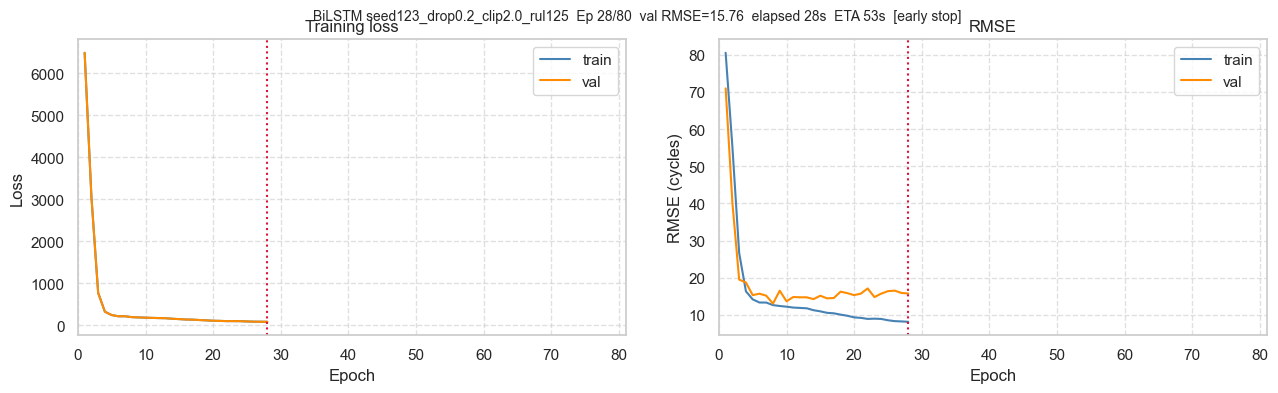

Best val RMSE = 13.043 at epoch 8
[seed123_drop0.2_clip2.0_rul125]
  RMSE=18.420  Score=498  MAE=15.502  Bias=+1.350

── LSTM sweep results (sorted by test RMSE) ──
                           tag  best_val      rmse       score      bias
 seed42_drop0.3_clip1.0_rul130 14.863618 16.267747  402.453522  1.526157
  seed7_drop0.3_clip1.0_rul130 16.730202 16.714714  375.982788 -1.179457
seed123_drop0.3_clip1.0_rul130 13.845830 16.969112  466.242584  1.853310
seed123_drop0.2_clip2.0_rul125 13.042631 18.419725  498.057220  1.349836
seed123_drop0.2_clip1.0_rul130 13.977095 19.055716  586.792847  3.813216
 seed42_drop0.2_clip2.0_rul125 13.962751 22.210457 1478.214233  8.450680
 seed42_drop0.2_clip1.0_rul130 15.426257 23.611232 1810.244141 11.478460
  seed7_drop0.2_clip2.0_rul125 15.364800 24.886158 1447.909302 -4.129615
  seed7_drop0.2_clip1.0_rul130 16.625224 26.651685 1558.295288 -6.897851


In [10]:
SEEDS   = [42, 7, 123]
CONFIGS = [
    dict(dropout=0.2, grad_clip=1.0, rul_clip=130),
    dict(dropout=0.3, grad_clip=1.0, rul_clip=130),
    dict(dropout=0.2, grad_clip=2.0, rul_clip=125),
]

BATCH = 256

sweep_results = []

for seed in SEEDS:
    set_seed(seed)
    sp = make_splits(fd1_train, fd2_train_global, fd2_train_cond,
                     fd1_test, fd2_test_global, fd2_test_cond,
                     fd1_true_rul, fd2_true_rul, seed=seed)
    for cfg in CONFIGS:
        set_seed(seed)
        tag = f"seed{seed}_drop{cfg['dropout']}_clip{cfg['grad_clip']}_rul{cfg['rul_clip']}"
        print(f"\n── LSTM sweep: {tag} ──")

        rng = np.random.default_rng(seed)
        src_units = fd1_train["unit"].unique()
        val_units = rng.choice(src_units, size=int(0.2 * len(src_units)), replace=False)
        vm = fd1_train["unit"].isin(val_units)
        tr_set = CMAPSSWindowDataset(fd1_train[~vm], USE_SENSORS, W, cfg["rul_clip"])
        vl_set = CMAPSSWindowDataset(fd1_train[ vm], USE_SENSORS, W, cfg["rul_clip"])
        tr_loader = DataLoader(tr_set, batch_size=BATCH, shuffle=True,  num_workers=0)
        vl_loader = DataLoader(vl_set, batch_size=BATCH, shuffle=False, num_workers=0)

        model = ImprovedLSTM(len(USE_SENSORS), dropout=cfg["dropout"])
        model, hist = train_lstm(
            model, tr_loader, vl_loader,
            n_epochs=80, lr=5e-4, weight_decay=1e-4,
            grad_clip=cfg["grad_clip"], patience=20,
            device=Device,
            ckpt_path=CKPT_DIR / f"lstm_{tag}.pt",
            tracker_title=f"BiLSTM {tag}",
            silent=False,
        )

        raw = run_inference(model, sp["X_test_fd1"], Device, mode="lstm")
        m   = score_predictions(sp["y_test_fd1"], raw, tag)
        sweep_results.append(dict(tag=tag, seed=seed, **cfg, **m,
                                  best_val=hist["val_rmse"].min()))

sweep_df = pd.DataFrame(sweep_results).sort_values("rmse")
print("\n── LSTM sweep results (sorted by test RMSE) ──")
print(sweep_df[["tag", "best_val", "rmse", "score", "bias"]].to_string(index=False))


## §11 · Best BiLSTM reload + FD001 metrics

In [11]:
best_row  = sweep_df.iloc[0]
best_tag  = best_row["tag"]
best_ckpt = CKPT_DIR / f"lstm_{best_tag}.pt"

set_seed(int(best_row["seed"]))
lstm_best = ImprovedLSTM(len(USE_SENSORS), dropout=best_row["dropout"])
sd = torch.load(best_ckpt, map_location=Device, weights_only=False)
lstm_best.load_state_dict(sd["model"])
lstm_best = lstm_best.to(Device)

raw_best_fd1 = run_inference(lstm_best, splits["X_test_fd1"], Device, mode="lstm")
lstm_fd1_metrics = score_predictions(splits["y_test_fd1"], raw_best_fd1,
                                     f"Best BiLSTM ({best_tag})")

with open(CKPT_DIR / "lstm_v7_best_results.json", "w") as f:
    json.dump({**lstm_fd1_metrics, "tag": best_tag}, f, indent=2)
sweep_df.to_csv(CKPT_DIR / "lstm_sweep.csv", index=False)


[Best BiLSTM (seed42_drop0.3_clip1.0_rul130)]
  RMSE=16.268  Score=402  MAE=13.160  Bias=+1.526


## §12 · Stage-aware batch sampler (for DANN/GRL/MMD)

In [12]:
class StageAwareBatchSampler:
    def __init__(self, src_dataset: CMAPSSWindowDataset,
                 tgt_dataset: CMAPSSWindowDataset,
                 batch_size: int = 128, rng_seed: int = 42):
        self.src = src_dataset
        self.tgt = tgt_dataset
        self.bs  = batch_size
        self.rng = np.random.default_rng(rng_seed)
        self.n_batches = math.ceil(len(src_dataset) / batch_size)

    def __len__(self): return self.n_batches

    def __iter__(self):
        for _ in range(self.n_batches):
            stage_sizes = [len(self.src.stage_indices[s]) for s in [0,1,2]]
            probs = np.array(stage_sizes, dtype=float)
            probs /= probs.sum()
            stage = self.rng.choice([0, 1, 2], p=probs)

            src_pool = self.src.stage_indices[stage]
            tgt_pool = self.tgt.stage_indices.get(stage, np.arange(len(self.tgt)))
            if len(tgt_pool) == 0:
                tgt_pool = np.arange(len(self.tgt))

            bs_src = min(self.bs, len(src_pool))
            bs_tgt = min(self.bs, len(tgt_pool))

            src_idx = self.rng.choice(src_pool, size=bs_src, replace=False)
            tgt_idx = self.rng.choice(tgt_pool, size=bs_tgt, replace=False)

            yield src_idx, tgt_idx


def collate_from_dataset(dataset, indices):
    X = torch.from_numpy(dataset.X[indices])
    y = torch.tensor(dataset.y[indices])
    return X, y


sp = splits
for stage, name in [(0, "late"), (1, "mid"), (2, "early")]:
    src_n = len(sp["fd1_train_set"].stage_indices[stage])
    tgt_n = len(sp["tgt_train_set"].stage_indices.get(stage, []))
    print(f"Stage {stage} ({name:5s}): FD001 src={src_n:5d}  FD002 tgt={tgt_n:5d}")


Stage 0 (late ): FD001 src= 2400  FD002 tgt= 7800
Stage 1 (mid  ): FD001 src= 4000  FD002 tgt=13000
Stage 2 (early): FD001 src= 7670  FD002 tgt=25419


## §13 · DANN model + tracker

In [13]:
class DomainHead(nn.Module):
    def __init__(self, enc_dim: int = 256):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(enc_dim, 64), nn.ReLU(), nn.Linear(64, 1))
    def forward(self, h): return self.net(h).squeeze(-1)


class DANNModel(nn.Module):
    def __init__(self, n_features: int, hidden: int = 128,
                 num_layers: int = 2, dropout: float = 0.2):
        super().__init__()
        self.encoder     = ImprovedLSTM(n_features, hidden, num_layers, dropout,
                                        bidirectional=True)
        enc_dim          = hidden * 2
        self.domain_head = DomainHead(enc_dim)
        self.grl         = GradientReversalLayer()

    def predict_rul(self, x):
        return self.encoder(x)

    def forward(self, x_src, x_tgt):
        h_src    = self.encoder.encode(x_src)
        h_tgt    = self.encoder.encode(x_tgt)
        rul_pred = self.encoder.head(h_src).squeeze(-1)
        h_all    = torch.cat([h_src, h_tgt], dim=0)
        dom_logits = self.domain_head(self.grl(h_all))
        return rul_pred, dom_logits


_m = DANNModel(len(USE_SENSORS)).to(Device)
print(f"DANN params: {sum(p.numel() for p in _m.parameters()):,}")
del _m


class DANNTracker:
    def __init__(self, n_epochs, plot_freq=1):
        self.n_epochs = n_epochs; self.plot_freq = plot_freq; self.epoch = 0
        self.total_loss, self.rul_loss, self.dom_loss, self.val_rmse, self.lam_hist = [],[],[],[],[]
        self._stopped_at = None; self.t0 = time.time()
        plt.ioff()
        self.fig, axes = plt.subplots(2, 2, figsize=(13, 7))
        (self.ax_tot, self.ax_val), (self.ax_rul, self.ax_dom) = axes
        self.c_tot, = self.ax_tot.plot([], [], color="steelblue")
        self.c_val, = self.ax_val.plot([], [], color="darkorange")
        self.c_rul, = self.ax_rul.plot([], [], color="seagreen")
        self.c_dom, = self.ax_dom.plot([], [], color="mediumpurple")
        self.ax_dom2 = self.ax_dom.twinx()
        self.c_lam,  = self.ax_dom2.plot([], [], color="gray", linestyle="--", alpha=0.7)
        for ax, t, yl in [(self.ax_tot,"Total loss","Loss"),(self.ax_val,"Val RMSE (FD001)","RMSE"),
                           (self.ax_rul,"RUL loss (MSE)","MSE"),(self.ax_dom,"Domain loss + lambda","BCE")]:
            ax.set_title(t); ax.set_xlabel("Epoch"); ax.set_ylabel(yl)
            ax.set_xlim(0, n_epochs+1); ax.grid(linestyle="--", alpha=0.6)
        self.ax_dom2.set_ylabel("lambda"); plt.tight_layout()

    def update_epoch(self, tot, rul, dom, vr, lam):
        self.total_loss.append(tot); self.rul_loss.append(rul)
        self.dom_loss.append(dom);   self.val_rmse.append(vr)
        self.lam_hist.append(lam);   self.epoch += 1
        if self.epoch % self.plot_freq == 0 or self.epoch == self.n_epochs:
            self._redraw()

    def mark_early_stop(self, ep): self._stopped_at = ep

    def _redraw(self):
        xs = list(range(1, self.epoch+1))
        for c, d, ax in [(self.c_tot,self.total_loss,self.ax_tot),
                          (self.c_val,self.val_rmse, self.ax_val),
                          (self.c_rul,self.rul_loss, self.ax_rul),
                          (self.c_dom,self.dom_loss, self.ax_dom)]:
            c.set_data(xs, d); ax.relim(); ax.autoscale_view()
        self.c_lam.set_data(xs, self.lam_hist)
        self.ax_dom2.relim(); self.ax_dom2.autoscale_view()
        if self._stopped_at:
            for ax in (self.ax_tot, self.ax_val, self.ax_rul, self.ax_dom):
                ax.axvline(self._stopped_at, color="crimson", linestyle=":", lw=1.5)
        elapsed = time.time()-self.t0
        eta = (elapsed/self.epoch)*(self.n_epochs-self.epoch)
        self.fig.suptitle(
            f"DANN  Ep {self.epoch}/{self.n_epochs}  val RMSE={self.val_rmse[-1]:.2f}  "
            f"lam={self.lam_hist[-1]:.3f}  elapsed {elapsed:.0f}s  ETA {eta:.0f}s"
            + ("  [early stop]" if self._stopped_at else ""), fontsize=10)
        clear_output(wait=True); display(self.fig)

    def close(self): plt.close(self.fig)


DANN params: 576,258


## §14 · DANN training loop (stage-aware)

In [14]:
def train_dann_stage_aware(
    model: DANNModel,
    src_dataset: CMAPSSWindowDataset,
    tgt_dataset: CMAPSSWindowDataset,
    val_loader: DataLoader,
    n_epochs: int = 50,
    lr: float = 5e-4,
    weight_decay: float = 1e-4,
    grad_clip: float = 1.0,
    patience: int = 20,
    lambda_max: float = 1.0,
    late_weight: float = 1.5,
    batch_size: int = 128,
    device: str = Device,
    ckpt_path: Optional[Path] = None,
    seed: int = 42,
    silent: bool = False,
):
    model   = model.to(device)
    opt     = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched   = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)
    dom_crit = nn.BCEWithLogitsLoss()

    sampler  = StageAwareBatchSampler(src_dataset, tgt_dataset,
                                      batch_size=batch_size, rng_seed=seed)
    tracker  = None if silent else DANNTracker(n_epochs)
    history  = []
    best_val, best_ep, no_imp = float("inf"), 0, 0
    best_state = None

    pbar = tqdm(range(1, n_epochs+1), desc="DANN", unit="epoch", disable=silent)
    for epoch in pbar:
        lam = ganin_lambda(epoch, n_epochs, high=lambda_max)
        model.grl.lam = lam
        model.train()
        ep_tot, ep_rul, ep_dom, ep_n = 0.0, 0.0, 0.0, 0

        for src_idx, tgt_idx in sampler:
            x_src, y_src = collate_from_dataset(src_dataset, src_idx)
            x_tgt, _     = collate_from_dataset(tgt_dataset, tgt_idx)
            x_src, y_src = x_src.to(device), y_src.to(device)
            x_tgt        = x_tgt.to(device)

            rul_pred, dom_logits = model(x_src, x_tgt)
            B_src = x_src.size(0); B_tgt = x_tgt.size(0)
            dom_labels = torch.cat([torch.zeros(B_src, device=device),
                                    torch.ones(B_tgt,  device=device)])

            l_rul = asymmetric_mse(rul_pred, y_src, late_weight)
            l_dom = dom_crit(dom_logits, dom_labels)
            loss  = l_rul + lam * l_dom

            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step()

            ep_tot += loss.item()*B_src; ep_rul += l_rul.item()*B_src
            ep_dom += l_dom.item()*B_src; ep_n  += B_src

        sched.step()
        _, val_rmse = evaluate_loader(model, val_loader, device, mode="dann")

        history.append(dict(epoch=epoch, total_loss=ep_tot/ep_n,
                            rul_loss=ep_rul/ep_n, dom_loss=ep_dom/ep_n,
                            val_rmse=val_rmse, lam=lam))
        if tracker: tracker.update_epoch(ep_tot/ep_n, ep_rul/ep_n, ep_dom/ep_n, val_rmse, lam)
        if not silent:
            pbar.set_postfix({"val_RMSE": f"{val_rmse:.2f}", "lam": f"{lam:.3f}", "no_imp": no_imp})

        if val_rmse < best_val:
            best_val, best_ep, no_imp = val_rmse, epoch, 0
            best_state = copy.deepcopy(model.state_dict())
            if ckpt_path:
                torch.save({"model": best_state, "epoch": epoch,
                            "val_rmse": val_rmse, "lam": lam}, ckpt_path)
        else:
            no_imp += 1
            if no_imp >= patience:
                if not silent: print(f"\nEarly stopping at epoch {epoch}.")
                if tracker: tracker.mark_early_stop(epoch); tracker._redraw()
                break

    if tracker: tracker.close()
    print(f"Best val RMSE = {best_val:.3f} at epoch {best_ep}")
    if best_state: model.load_state_dict(best_state)
    return model, pd.DataFrame(history)


## §15 · DANN 3-seed sweep

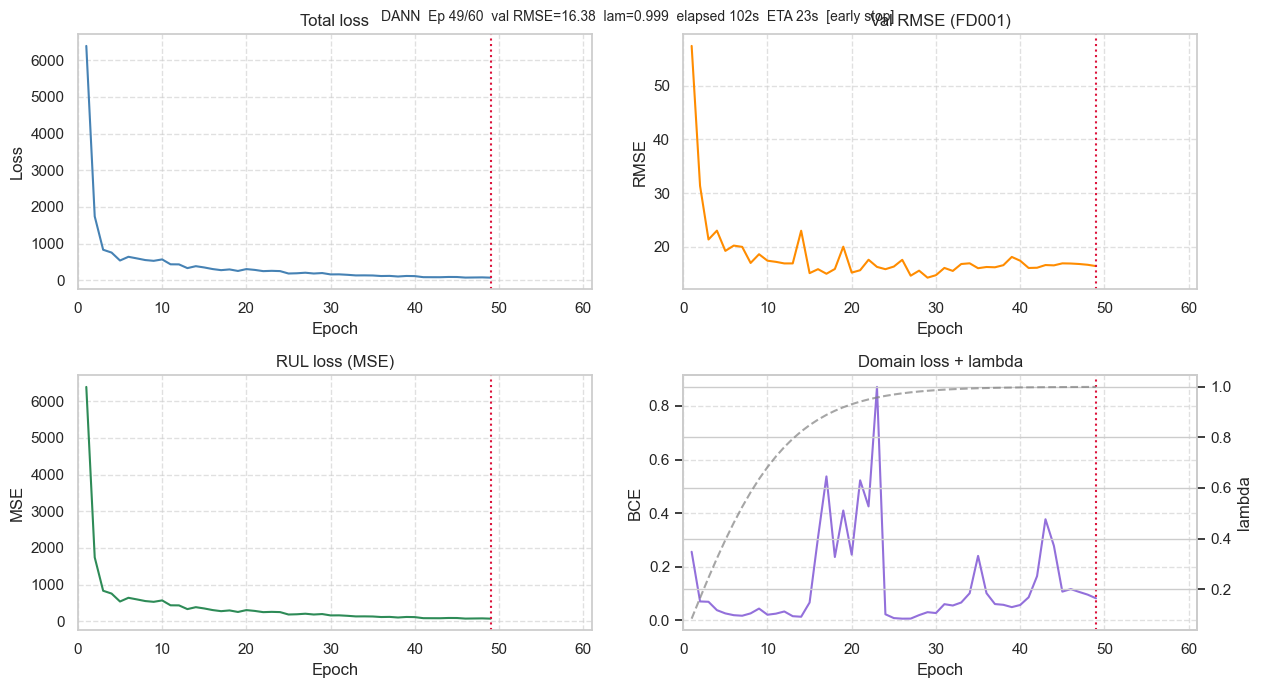

Best val RMSE = 14.231 at epoch 29
[dann_seed123_drop0.2_clip2.0]
  RMSE=78.753  Score=16938096  MAE=63.659  Bias=-44.589

── DANN sweep results (sorted by test RMSE) ──
                         tag  best_val      rmse        score       bias   lb_rmse
  dann_seed7_drop0.2_clip2.0 17.406535 54.878161 3.516256e+05  11.653319 59.396515
  dann_seed7_drop0.2_clip1.0 18.148523 55.908080 4.359290e+05  13.642056 59.396515
dann_seed123_drop0.3_clip1.0 14.177065 57.916810 9.772075e+05  21.026079 59.396515
 dann_seed42_drop0.2_clip1.0 15.622189 58.038210 3.022381e+05 -13.322142 59.396515
 dann_seed42_drop0.2_clip2.0 15.054176 59.279631 9.966145e+05  24.723726 59.396515
  dann_seed7_drop0.3_clip1.0 17.166621 60.194476 2.164711e+06  20.392817 59.396515
 dann_seed42_drop0.3_clip1.0 15.212369 64.334738 2.496895e+06  33.183693 59.396515
dann_seed123_drop0.2_clip2.0 14.231228 78.753218 1.693810e+07 -44.589466 59.396515
dann_seed123_drop0.2_clip1.0 15.515151 96.325544 3.001124e+07 -79.223381 59.396515


In [15]:
DANN_BATCH = 128

dann_sweep_results = []

for seed in SEEDS:
    set_seed(seed)
    sp = make_splits(fd1_train, fd2_train_global, fd2_train_cond,
                     fd1_test, fd2_test_global, fd2_test_cond,
                     fd1_true_rul, fd2_true_rul, seed=seed)

    src_val_loader = DataLoader(sp["fd1_val_set"], batch_size=256, shuffle=False, num_workers=0)

    raw_lb = run_inference(lstm_best, sp["X_test_fd2_global"], Device, mode="lstm")
    lb_m   = score_predictions(sp["y_test_fd2"], raw_lb, f"LB seed={seed}")

    for cfg in CONFIGS:
        set_seed(seed)
        tag = f"dann_seed{seed}_drop{cfg['dropout']}_clip{cfg['grad_clip']}"
        print(f"\n── DANN sweep: {tag} ──")

        dann = DANNModel(n_features=len(USE_SENSORS), dropout=cfg["dropout"])
        dann, hist = train_dann_stage_aware(
            dann,
            src_dataset=sp["fd1_train_set"],
            tgt_dataset=sp["tgt_train_set"],
            val_loader=src_val_loader,
            n_epochs=60, lr=5e-4, weight_decay=1e-4,
            grad_clip=cfg["grad_clip"], patience=20,
            lambda_max=1.0, late_weight=1.5,
            batch_size=DANN_BATCH,
            device=Device,
            ckpt_path=CKPT_DIR / f"{tag}.pt",
            seed=seed,
        )

        raw = run_inference(dann, sp["X_test_fd2_global"], Device, mode="dann")
        m   = score_predictions(sp["y_test_fd2"], raw, tag)
        dann_sweep_results.append(dict(tag=tag, seed=seed, **cfg, **m,
                                       best_val=hist["val_rmse"].min(),
                                       lb_rmse=lb_m["rmse"]))

dann_sweep_df = pd.DataFrame(dann_sweep_results).sort_values("rmse")
print("\n── DANN sweep results (sorted by test RMSE) ──")
print(dann_sweep_df[["tag", "best_val", "rmse", "score", "bias", "lb_rmse"]].to_string(index=False))


## §16 · Best DANN

In [16]:
best_dann_row  = dann_sweep_df.iloc[0]
best_dann_tag  = best_dann_row["tag"]
best_dann_ckpt = CKPT_DIR / f"{best_dann_tag}.pt"

dann_best = DANNModel(n_features=len(USE_SENSORS), dropout=best_dann_row["dropout"])
sd = torch.load(best_dann_ckpt, map_location=Device, weights_only=False)
dann_best.load_state_dict(sd["model"])
dann_best = dann_best.to(Device)

raw_dann = run_inference(dann_best, splits["X_test_fd2_global"], Device, mode="dann")
dann_metrics = score_predictions(splits["y_test_fd2"], raw_dann,
                                 f"Best DANN ({best_dann_tag})")
dann_sweep_df.to_csv(CKPT_DIR / "dann_sweep.csv", index=False)


[Best DANN (dann_seed7_drop0.2_clip2.0)]
  RMSE=54.878  Score=351626  MAE=46.020  Bias=+11.653


## §17 · LSTM-GRL model

In [17]:
class LSTMWithGRL(nn.Module):
    def __init__(self, n_features: int, hidden: int = 128,
                 num_layers: int = 2, dropout: float = 0.2):
        super().__init__()
        self.lstm_body   = ImprovedLSTM(n_features, hidden, num_layers, dropout,
                                        bidirectional=True)
        enc_dim          = hidden * 2
        self.domain_head = DomainHead(enc_dim)
        self.grl         = GradientReversalLayer()

    def predict_rul(self, x): return self.lstm_body(x)

    def forward(self, x_src, x_tgt):
        h_src = self.lstm_body.encode(x_src)
        h_tgt = self.lstm_body.encode(x_tgt)
        rul_pred   = self.lstm_body.head(h_src).squeeze(-1)
        h_all      = torch.cat([h_src, h_tgt], dim=0)
        dom_logits = self.domain_head(self.grl(h_all))
        return rul_pred, dom_logits


_m = LSTMWithGRL(len(USE_SENSORS)).to(Device)
print(f"LSTM-GRL params: {sum(p.numel() for p in _m.parameters()):,}")
del _m


LSTM-GRL params: 576,258


## §18 · GRL two-phase training

In [18]:
def train_grl_two_phase(
    model: LSTMWithGRL,
    src_dataset: CMAPSSWindowDataset,
    tgt_dataset: CMAPSSWindowDataset,
    val_loader: DataLoader,
    phase1_epochs: int = 15,
    phase2_epochs: int = 35,
    lr: float = 5e-4,
    weight_decay: float = 1e-4,
    grad_clip: float = 1.0,
    patience: int = 20,
    lambda_max: float = 1.0,
    late_weight: float = 1.5,
    batch_size: int = 128,
    device: str = Device,
    ckpt_path: Optional[Path] = None,
    seed: int = 42,
    silent: bool = False,
):
    n_epochs = phase1_epochs + phase2_epochs
    model    = model.to(device)
    opt      = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched    = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)
    dom_crit = nn.BCEWithLogitsLoss()

    sampler  = StageAwareBatchSampler(src_dataset, tgt_dataset,
                                      batch_size=batch_size, rng_seed=seed)
    tracker  = None if silent else DANNTracker(n_epochs)
    history  = []
    best_val, best_ep, no_imp = float("inf"), 0, 0
    best_state = None

    pbar = tqdm(range(1, n_epochs+1), desc="GRL-2phase", unit="epoch", disable=silent)
    for epoch in pbar:
        if epoch <= phase1_epochs:
            lam = 0.0
        else:
            p2_epoch = epoch - phase1_epochs
            lam = ganin_lambda(p2_epoch, phase2_epochs, high=lambda_max)

        model.grl.lam = lam
        model.train()
        ep_tot, ep_rul, ep_dom, ep_n = 0.0, 0.0, 0.0, 0

        for src_idx, tgt_idx in sampler:
            x_src, y_src = collate_from_dataset(src_dataset, src_idx)
            x_tgt, _     = collate_from_dataset(tgt_dataset, tgt_idx)
            x_src, y_src = x_src.to(device), y_src.to(device)
            x_tgt        = x_tgt.to(device)

            rul_pred, dom_logits = model(x_src, x_tgt)
            B_src = x_src.size(0); B_tgt = x_tgt.size(0)
            dom_labels = torch.cat([torch.zeros(B_src, device=device),
                                    torch.ones(B_tgt,  device=device)])

            l_rul = asymmetric_mse(rul_pred, y_src, late_weight)
            l_dom = dom_crit(dom_logits, dom_labels)
            loss  = l_rul + lam * l_dom

            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step()

            ep_tot += loss.item()*B_src; ep_rul += l_rul.item()*B_src
            ep_dom += l_dom.item()*B_src; ep_n  += B_src

        sched.step()
        _, val_rmse = evaluate_loader(model, val_loader, device, mode="dann")

        phase_str = "P1" if epoch <= phase1_epochs else "P2"
        history.append(dict(epoch=epoch, phase=phase_str,
                            total_loss=ep_tot/ep_n, rul_loss=ep_rul/ep_n,
                            dom_loss=ep_dom/ep_n, val_rmse=val_rmse, lam=lam))
        if tracker: tracker.update_epoch(ep_tot/ep_n, ep_rul/ep_n, ep_dom/ep_n, val_rmse, lam)
        if not silent:
            pbar.set_postfix({"phase": phase_str, "val": f"{val_rmse:.2f}",
                              "lam": f"{lam:.3f}", "no_imp": no_imp})

        if val_rmse < best_val:
            best_val, best_ep, no_imp = val_rmse, epoch, 0
            best_state = copy.deepcopy(model.state_dict())
            if ckpt_path:
                torch.save({"model": best_state, "epoch": epoch,
                            "val_rmse": val_rmse}, ckpt_path)
        else:
            no_imp += 1
            if no_imp >= patience:
                if not silent: print(f"\nEarly stopping at epoch {epoch}.")
                if tracker: tracker.mark_early_stop(epoch); tracker._redraw()
                break

    if tracker: tracker.close()
    print(f"Best val RMSE = {best_val:.3f} at epoch {best_ep}")
    if best_state: model.load_state_dict(best_state)
    return model, pd.DataFrame(history)


## §19 · GRL 3-seed sweep

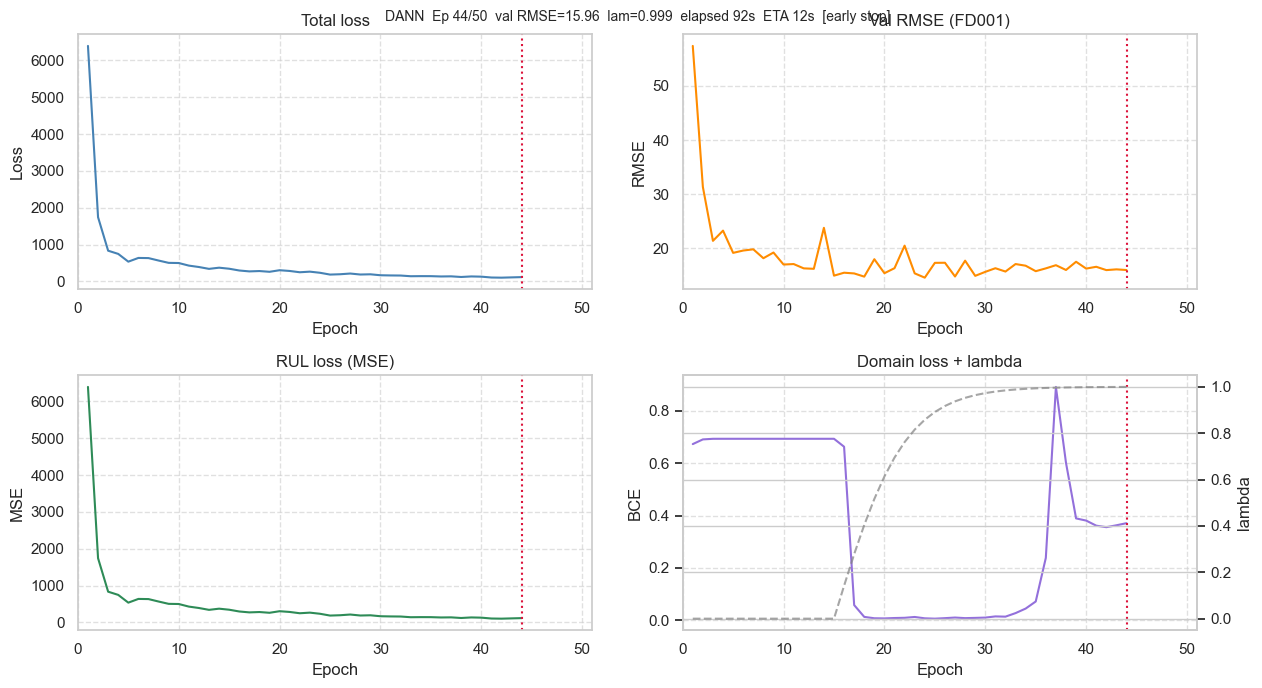

Best val RMSE = 14.548 at epoch 24
[grl_seed123_drop0.2_clip2.0 FD002]
  RMSE=77.126  Score=11971862  MAE=61.023  Bias=-42.982
[grl_seed123_drop0.2_clip2.0 FD001]
  RMSE=25.885  Score=1895  MAE=22.134  Bias=+11.787

── GRL sweep results (sorted by FD002 RMSE) ──
                        tag  best_val  fd1_rmse  fd2_rmse    fd2_score
  grl_seed7_drop0.2_clip1.0 18.328254 28.632399 54.822058 4.589933e+05
  grl_seed7_drop0.2_clip2.0 16.714684 25.105555 57.107958 8.641896e+05
  grl_seed7_drop0.3_clip1.0 17.274015 18.794639 57.317805 7.811280e+05
 grl_seed42_drop0.2_clip2.0 15.148453 20.481036 57.854889 7.321937e+05
 grl_seed42_drop0.2_clip1.0 15.369519 20.737407 58.946093 9.941992e+05
grl_seed123_drop0.3_clip1.0 14.862371 22.407978 61.174080 1.969302e+06
 grl_seed42_drop0.3_clip1.0 15.332984 17.644624 63.243272 1.884671e+06
grl_seed123_drop0.2_clip2.0 14.547727 25.885373 77.126257 1.197186e+07
grl_seed123_drop0.2_clip1.0 14.844431 28.115964 97.378440 3.127432e+07


In [19]:
grl_sweep_results = []

for seed in SEEDS:
    set_seed(seed)
    sp = make_splits(fd1_train, fd2_train_global, fd2_train_cond,
                     fd1_test, fd2_test_global, fd2_test_cond,
                     fd1_true_rul, fd2_true_rul, seed=seed)
    src_val_loader = DataLoader(sp["fd1_val_set"], batch_size=256, shuffle=False, num_workers=0)

    for cfg in CONFIGS:
        set_seed(seed)
        tag = f"grl_seed{seed}_drop{cfg['dropout']}_clip{cfg['grad_clip']}"
        print(f"\n── GRL sweep: {tag} ──")

        grl = LSTMWithGRL(n_features=len(USE_SENSORS), dropout=cfg["dropout"])
        grl, hist = train_grl_two_phase(
            grl,
            src_dataset=sp["fd1_train_set"],
            tgt_dataset=sp["tgt_train_set"],
            val_loader=src_val_loader,
            phase1_epochs=15, phase2_epochs=35,
            lr=5e-4, weight_decay=1e-4,
            grad_clip=cfg["grad_clip"], patience=20,
            lambda_max=1.0, late_weight=1.5,
            batch_size=DANN_BATCH,
            device=Device,
            ckpt_path=CKPT_DIR / f"{tag}.pt",
            seed=seed,
        )

        raw_fd2 = run_inference(grl, sp["X_test_fd2_global"], Device, mode="dann")
        raw_fd1 = run_inference(grl, sp["X_test_fd1"],        Device, mode="dann")
        m_fd2   = score_predictions(sp["y_test_fd2"], raw_fd2, f"{tag} FD002")
        m_fd1   = score_predictions(sp["y_test_fd1"], raw_fd1, f"{tag} FD001")
        grl_sweep_results.append(dict(tag=tag, seed=seed, **cfg,
                                       fd2_rmse=m_fd2["rmse"], fd2_score=m_fd2["score"],
                                       fd1_rmse=m_fd1["rmse"],
                                       best_val=hist["val_rmse"].min()))

grl_sweep_df = pd.DataFrame(grl_sweep_results).sort_values("fd2_rmse")
print("\n── GRL sweep results (sorted by FD002 RMSE) ──")
print(grl_sweep_df[["tag","best_val","fd1_rmse","fd2_rmse","fd2_score"]].to_string(index=False))


## §20 · Best GRL

In [20]:
best_grl_row  = grl_sweep_df.iloc[0]
best_grl_tag  = best_grl_row["tag"]
best_grl_ckpt = CKPT_DIR / f"{best_grl_tag}.pt"

grl_best = LSTMWithGRL(n_features=len(USE_SENSORS), dropout=best_grl_row["dropout"])
sd = torch.load(best_grl_ckpt, map_location=Device, weights_only=False)
grl_best.load_state_dict(sd["model"])
grl_best = grl_best.to(Device)

raw_grl_fd2 = run_inference(grl_best, splits["X_test_fd2_global"], Device, mode="dann")
raw_grl_fd1 = run_inference(grl_best, splits["X_test_fd1"],        Device, mode="dann")
grl_fd2_metrics = score_predictions(splits["y_test_fd2"], raw_grl_fd2,
                                    f"Best GRL ({best_grl_tag}) on FD002")
grl_fd1_metrics = score_predictions(splits["y_test_fd1"], raw_grl_fd1,
                                    f"Best GRL ({best_grl_tag}) on FD001")
grl_sweep_df.to_csv(CKPT_DIR / "grl_sweep.csv", index=False)


[Best GRL (grl_seed7_drop0.2_clip1.0) on FD002]
  RMSE=54.822  Score=458993  MAE=45.630  Bias=+7.715
[Best GRL (grl_seed7_drop0.2_clip1.0) on FD001]
  RMSE=28.632  Score=5570  MAE=23.417  Bias=+9.027


## §21 · Upper-bound sweep (supervised on FD002)

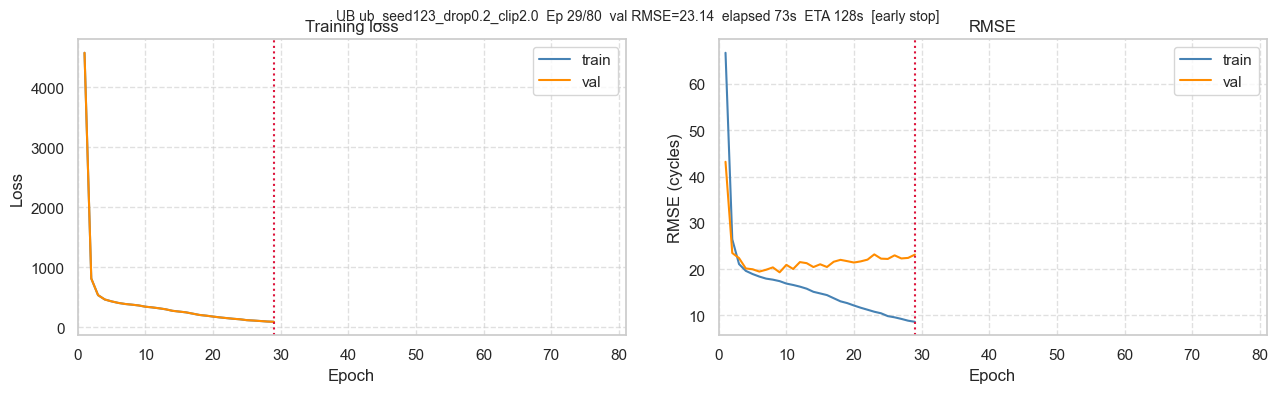

Best val RMSE = 19.323 at epoch 9
[ub_seed123_drop0.2_clip2.0]
  RMSE=28.423  Score=12278  MAE=19.493  Bias=-10.119

── Upper bound sweep results ──
                       tag  best_val      rmse        score       bias
  ub_seed7_drop0.2_clip1.0 18.464638 27.178470 10705.698242  -7.424264
  ub_seed7_drop0.2_clip2.0 18.805604 27.708433 13766.311523  -9.311122
  ub_seed7_drop0.3_clip1.0 18.469377 28.031731 12010.508789  -8.622762
ub_seed123_drop0.3_clip1.0 18.805730 28.101757 12923.806641  -9.268451
 ub_seed42_drop0.2_clip2.0 17.261859 28.122636 13441.903320  -8.348880
ub_seed123_drop0.2_clip2.0 19.323117 28.422551 12278.050781 -10.119297
 ub_seed42_drop0.3_clip1.0 17.379223 28.629298 12849.509766  -8.522470
ub_seed123_drop0.2_clip1.0 19.478473 29.192377 15074.017578  -9.755082
 ub_seed42_drop0.2_clip1.0 18.208575 29.650916 16662.798828 -10.582562
[Best upper bound]
  RMSE=27.178  Score=10706  MAE=18.767  Bias=-7.424


In [21]:
ub_sweep_results = []

for seed in SEEDS:
    set_seed(seed)
    sp = make_splits(fd1_train, fd2_train_global, fd2_train_cond,
                     fd1_test, fd2_test_global, fd2_test_cond,
                     fd1_true_rul, fd2_true_rul, seed=seed)

    for cfg in CONFIGS:
        set_seed(seed)
        tag = f"ub_seed{seed}_drop{cfg['dropout']}_clip{cfg['grad_clip']}"
        print(f"\n── Upper bound sweep: {tag} ──")

        fd2_tr_loader = DataLoader(sp["fd2_train_set"], batch_size=256, shuffle=True,  num_workers=0)
        fd2_vl_loader = DataLoader(sp["fd2_val_set"],   batch_size=256, shuffle=False, num_workers=0)

        model = ImprovedLSTM(len(USE_SENSORS), dropout=cfg["dropout"])
        model, hist = train_lstm(
            model, fd2_tr_loader, fd2_vl_loader,
            n_epochs=80, lr=5e-4, weight_decay=1e-4,
            grad_clip=cfg["grad_clip"], patience=20,
            device=Device,
            ckpt_path=CKPT_DIR / f"{tag}.pt",
            tracker_title=f"UB {tag}",
            silent=False,
        )

        raw = run_inference(model, sp["X_test_fd2_cond"], Device, mode="lstm")
        m   = score_predictions(sp["y_test_fd2"], raw, tag)
        ub_sweep_results.append(dict(tag=tag, seed=seed, **cfg, **m,
                                     best_val=hist["val_rmse"].min()))

ub_sweep_df = pd.DataFrame(ub_sweep_results).sort_values("rmse")
print("\n── Upper bound sweep results ──")
print(ub_sweep_df[["tag", "best_val", "rmse", "score", "bias"]].to_string(index=False))

ub_best_row = ub_sweep_df.iloc[0]
ub_best_ckpt = CKPT_DIR / f"{ub_best_row['tag']}.pt"
lstm_ub = ImprovedLSTM(len(USE_SENSORS), dropout=ub_best_row["dropout"])
sd = torch.load(ub_best_ckpt, map_location=Device, weights_only=False)
lstm_ub.load_state_dict(sd["model"])
lstm_ub = lstm_ub.to(Device)
raw_ub = run_inference(lstm_ub, splits["X_test_fd2_cond"], Device, mode="lstm")
ub_metrics = score_predictions(splits["y_test_fd2"], raw_ub, "Best upper bound")
ub_sweep_df.to_csv(CKPT_DIR / "ub_sweep.csv", index=False)


## §22 · Lower bound + DANN/GRL gap analysis

In [22]:
raw_lb = run_inference(lstm_best, splits["X_test_fd2_global"], Device, mode="lstm")
lb_metrics = score_predictions(splits["y_test_fd2"], raw_lb, "Lower bound (BiLSTM, no adapt.)")

def gap(lb, adapt, ub):
    if abs(lb - ub) < 1e-6: return float("nan")
    return (lb - adapt) / (lb - ub) * 100

dann_gap_rmse  = gap(lb_metrics["rmse"],  dann_metrics["rmse"],    ub_metrics["rmse"])
dann_gap_score = gap(lb_metrics["score"], dann_metrics["score"],   ub_metrics["score"])
grl_gap_rmse   = gap(lb_metrics["rmse"],  grl_fd2_metrics["rmse"], ub_metrics["rmse"])
grl_gap_score  = gap(lb_metrics["score"], grl_fd2_metrics["score"],ub_metrics["score"])

print(f"\nDANN closed {dann_gap_rmse:.1f}% of RMSE gap | {dann_gap_score:.1f}% of score gap")
print(f"GRL  closed {grl_gap_rmse:.1f}% of RMSE gap | {grl_gap_score:.1f}% of score gap")


[Lower bound (BiLSTM, no adapt.)]
  RMSE=59.397  Score=460786  MAE=48.913  Bias=-16.689

DANN closed 14.0% of RMSE gap | 24.3% of score gap
GRL  closed 14.2% of RMSE gap | 0.4% of score gap


---

## §23 · MMD addon — Contribution 3

Multi-kernel Gaussian MMD as a third alternative to GRL/DANN. No adversary, no min-max game; alignment comes from minimizing kernel distance between encoded source and target features.


In [23]:
def gaussian_kernel(source, target, kernel_mul=2.0, kernel_num=5, fix_sigma=None):
    n_samples = int(source.size(0)) + int(target.size(0))
    total = torch.cat([source, target], dim=0)
    total0 = total.unsqueeze(0).expand(n_samples, -1, -1)
    total1 = total.unsqueeze(1).expand(-1, n_samples, -1)
    L2_distance = ((total0 - total1) ** 2).sum(dim=2)
    if fix_sigma is None:
        bandwidth = torch.sum(L2_distance.detach()) / (n_samples ** 2 - n_samples)
    else:
        bandwidth = fix_sigma
    bandwidth /= kernel_mul ** (kernel_num // 2)
    bandwidth_list = [bandwidth * (kernel_mul ** i) for i in range(kernel_num)]
    kernel_val = sum(torch.exp(-L2_distance / b) for b in bandwidth_list)
    return kernel_val


def mmd_loss(source_features, target_features, kernel_mul=2.0, kernel_num=5):
    n_src = source_features.size(0)
    n_tgt = target_features.size(0)
    kernels = gaussian_kernel(source_features, target_features, kernel_mul, kernel_num)
    XX = kernels[:n_src, :n_src]
    YY = kernels[n_src:, n_src:]
    XY = kernels[:n_src, n_src:]
    YX = kernels[n_src:, :n_src]
    loss = XX.mean() + YY.mean() - XY.mean() - YX.mean()
    return loss


class LSTMWithMMD(nn.Module):
    def __init__(self, n_features, hidden=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm_body = ImprovedLSTM(n_features, hidden, num_layers, dropout,
                                      bidirectional=True)

    def encode(self, x):
        return self.lstm_body.encode(x)

    def predict_rul(self, x):
        return self.lstm_body(x)

    def forward(self, x_src, x_tgt):
        h_src = self.lstm_body.encode(x_src)
        h_tgt = self.lstm_body.encode(x_tgt)
        rul_pred = self.lstm_body.head(h_src).squeeze(-1)
        return rul_pred, h_src, h_tgt


_m = LSTMWithMMD(len(USE_SENSORS)).to(Device)
print(f"LSTM-MMD params: {sum(p.numel() for p in _m.parameters()):,}")

_a = torch.randn(64, 256, device=Device)
_b = torch.randn(64, 256, device=Device) + 0.5
print(f"MMD self-distance (should be ~0)  : {mmd_loss(_a, _a).item():.6f}")
print(f"MMD shifted distance (should be >0): {mmd_loss(_a, _b).item():.6f}")
del _m, _a, _b


LSTM-MMD params: 559,745
MMD self-distance (should be ~0)  : 0.000000
MMD shifted distance (should be >0): 0.363187


## §24 · MMDTracker + train_mmd_two_phase

In [24]:
class MMDTracker:
    def __init__(self, n_epochs, plot_freq=1):
        self.n_epochs = n_epochs; self.plot_freq = plot_freq; self.epoch = 0
        self.total_loss, self.rul_loss, self.mmd_loss_v, self.val_rmse, self.lam_hist = [],[],[],[],[]
        self._stopped_at = None; self.t0 = time.time()
        plt.ioff()
        self.fig, axes = plt.subplots(2, 2, figsize=(13, 7))
        (self.ax_tot, self.ax_val), (self.ax_rul, self.ax_mmd) = axes
        self.c_tot, = self.ax_tot.plot([], [], color="steelblue")
        self.c_val, = self.ax_val.plot([], [], color="darkorange")
        self.c_rul, = self.ax_rul.plot([], [], color="seagreen")
        self.c_mmd, = self.ax_mmd.plot([], [], color="mediumpurple")
        self.ax_mmd2 = self.ax_mmd.twinx()
        self.c_lam,  = self.ax_mmd2.plot([], [], color="gray", linestyle="--", alpha=0.7)
        for ax, t, yl in [(self.ax_tot,"Total loss","Loss"),
                          (self.ax_val,"Val RMSE (FD001)","RMSE"),
                          (self.ax_rul,"RUL loss (asym MSE)","MSE"),
                          (self.ax_mmd,"MMD loss + lambda","MMD")]:
            ax.set_title(t); ax.set_xlabel("Epoch"); ax.set_ylabel(yl)
            ax.set_xlim(0, n_epochs+1); ax.grid(linestyle="--", alpha=0.6)
        self.ax_mmd2.set_ylabel("lambda"); plt.tight_layout()

    def update_epoch(self, tot, rul, mmd_v, vr, lam):
        self.total_loss.append(tot); self.rul_loss.append(rul)
        self.mmd_loss_v.append(mmd_v); self.val_rmse.append(vr)
        self.lam_hist.append(lam); self.epoch += 1
        if self.epoch % self.plot_freq == 0 or self.epoch == self.n_epochs:
            self._redraw()

    def mark_early_stop(self, ep): self._stopped_at = ep

    def _redraw(self):
        xs = list(range(1, self.epoch+1))
        for c, d, ax in [(self.c_tot,self.total_loss,self.ax_tot),
                         (self.c_val,self.val_rmse, self.ax_val),
                         (self.c_rul,self.rul_loss, self.ax_rul),
                         (self.c_mmd,self.mmd_loss_v,self.ax_mmd)]:
            c.set_data(xs, d); ax.relim(); ax.autoscale_view()
        self.c_lam.set_data(xs, self.lam_hist)
        self.ax_mmd2.relim(); self.ax_mmd2.autoscale_view()
        if self._stopped_at:
            for ax in (self.ax_tot, self.ax_val, self.ax_rul, self.ax_mmd):
                ax.axvline(self._stopped_at, color="crimson", linestyle=":", lw=1.5)
        elapsed = time.time()-self.t0
        eta = (elapsed/self.epoch)*(self.n_epochs-self.epoch)
        self.fig.suptitle(
            f"MMD  Ep {self.epoch}/{self.n_epochs}  val RMSE={self.val_rmse[-1]:.2f}  "
            f"lam={self.lam_hist[-1]:.3f}  elapsed {elapsed:.0f}s  ETA {eta:.0f}s"
            + ("  [early stop]" if self._stopped_at else ""), fontsize=10)
        clear_output(wait=True); display(self.fig)

    def close(self): plt.close(self.fig)


def train_mmd_two_phase(
    model, src_dataset, tgt_dataset, val_loader,
    phase1_epochs=15, phase2_epochs=35,
    lr=5e-4, weight_decay=1e-4, grad_clip=1.0, patience=20,
    lambda_max=1.0, late_weight=1.5, batch_size=128,
    kernel_num=5, kernel_mul=2.0,
    device=None, ckpt_path=None, seed=42, silent=False,
):
    if device is None: device = Device
    n_epochs = phase1_epochs + phase2_epochs
    model    = model.to(device)
    opt      = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched    = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)

    sampler  = StageAwareBatchSampler(src_dataset, tgt_dataset,
                                      batch_size=batch_size, rng_seed=seed)
    tracker  = None if silent else MMDTracker(n_epochs)
    history  = []
    best_val, best_ep, no_imp = float("inf"), 0, 0
    best_state = None

    pbar = tqdm(range(1, n_epochs+1), desc="MMD-2phase", unit="epoch", disable=silent)
    for epoch in pbar:
        if epoch <= phase1_epochs:
            lam = 0.0
        else:
            p2_epoch = epoch - phase1_epochs
            lam = ganin_lambda(p2_epoch, phase2_epochs, high=lambda_max)

        model.train()
        ep_tot, ep_rul, ep_mmd, ep_n = 0.0, 0.0, 0.0, 0

        for src_idx, tgt_idx in sampler:
            x_src, y_src = collate_from_dataset(src_dataset, src_idx)
            x_tgt, _     = collate_from_dataset(tgt_dataset, tgt_idx)
            x_src, y_src = x_src.to(device), y_src.to(device)
            x_tgt        = x_tgt.to(device)

            rul_pred, h_src, h_tgt = model(x_src, x_tgt)
            B_src = x_src.size(0)

            l_rul = asymmetric_mse(rul_pred, y_src, late_weight)
            if lam > 0:
                l_mmd = mmd_loss(h_src, h_tgt, kernel_mul=kernel_mul, kernel_num=kernel_num)
            else:
                with torch.no_grad():
                    l_mmd = mmd_loss(h_src, h_tgt, kernel_mul=kernel_mul, kernel_num=kernel_num)
            loss = l_rul + lam * l_mmd

            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step()

            ep_tot += loss.item()*B_src
            ep_rul += l_rul.item()*B_src
            ep_mmd += float(l_mmd.item())*B_src
            ep_n  += B_src

        sched.step()
        _, val_rmse = evaluate_loader(model, val_loader, device, mode="dann")

        phase_str = "P1" if epoch <= phase1_epochs else "P2"
        history.append(dict(epoch=epoch, phase=phase_str,
                            total_loss=ep_tot/ep_n, rul_loss=ep_rul/ep_n,
                            mmd_loss=ep_mmd/ep_n, val_rmse=val_rmse, lam=lam))
        if tracker: tracker.update_epoch(ep_tot/ep_n, ep_rul/ep_n, ep_mmd/ep_n, val_rmse, lam)
        if not silent:
            pbar.set_postfix({"phase": phase_str, "val": f"{val_rmse:.2f}",
                              "lam": f"{lam:.3f}", "no_imp": no_imp})

        if val_rmse < best_val:
            best_val, best_ep, no_imp = val_rmse, epoch, 0
            best_state = copy.deepcopy(model.state_dict())
            if ckpt_path:
                torch.save({"model": best_state, "epoch": epoch,
                            "val_rmse": val_rmse}, ckpt_path)
        else:
            no_imp += 1
            if no_imp >= patience:
                if not silent: print(f"\nEarly stopping at epoch {epoch}.")
                if tracker: tracker.mark_early_stop(epoch); tracker._redraw()
                break

    if tracker: tracker.close()
    if best_state is not None:
        model.load_state_dict(best_state)
    print(f"Best val RMSE = {best_val:.3f} at epoch {best_ep}")
    return model, pd.DataFrame(history)


## §25 · MMD 3-seed sweep

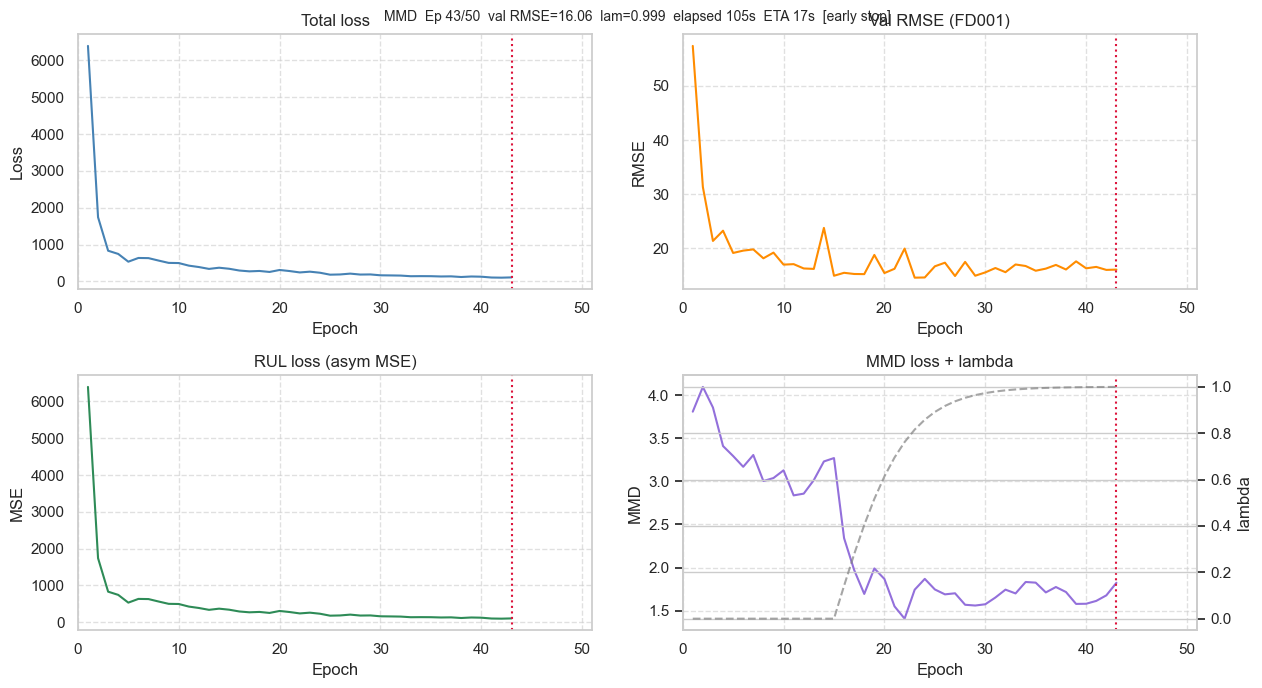

Best val RMSE = 14.566 at epoch 23
[mmd_seed123_drop0.2_clip2.0 FD002]
  RMSE=83.005  Score=18881452  MAE=66.576  Bias=-52.634
[mmd_seed123_drop0.2_clip2.0 FD001]
  RMSE=25.254  Score=1722  MAE=21.637  Bias=+11.649

── MMD sweep results (sorted by FD002 RMSE) ──
                        tag  best_val  fd1_rmse  fd2_rmse    fd2_score
 mmd_seed42_drop0.2_clip2.0 15.012803 20.683066 56.331896   407693.750
 mmd_seed42_drop0.3_clip1.0 15.354490 17.702871 61.089204  1305628.375
  mmd_seed7_drop0.2_clip1.0 18.333577 28.335596 65.674193  2283710.250
 mmd_seed42_drop0.2_clip1.0 15.261411 21.062753 68.340603  1663425.250
  mmd_seed7_drop0.2_clip2.0 17.016911 25.861719 68.668282  3722337.750
mmd_seed123_drop0.2_clip1.0 15.082803 27.742154 70.337652  5008296.500
  mmd_seed7_drop0.3_clip1.0 17.035411 19.005454 71.449324  7037697.000
mmd_seed123_drop0.3_clip1.0 14.870406 22.478242 77.508562  8324200.000
mmd_seed123_drop0.2_clip2.0 14.565862 25.253709 83.004868 18881452.000


In [25]:
mmd_sweep_results = []

for seed in SEEDS:
    set_seed(seed)
    sp = make_splits(fd1_train, fd2_train_global, fd2_train_cond,
                     fd1_test, fd2_test_global, fd2_test_cond,
                     fd1_true_rul, fd2_true_rul, seed=seed)
    src_val_loader = DataLoader(sp["fd1_val_set"], batch_size=256, shuffle=False, num_workers=0)

    for cfg in CONFIGS:
        set_seed(seed)
        tag = f"mmd_seed{seed}_drop{cfg['dropout']}_clip{cfg['grad_clip']}"
        print(f"\n── MMD sweep: {tag} ──")

        mmd_model = LSTMWithMMD(n_features=len(USE_SENSORS), dropout=cfg["dropout"])
        mmd_model, hist = train_mmd_two_phase(
            mmd_model,
            src_dataset=sp["fd1_train_set"],
            tgt_dataset=sp["tgt_train_set"],
            val_loader=src_val_loader,
            phase1_epochs=15, phase2_epochs=35,
            lr=5e-4, weight_decay=1e-4,
            grad_clip=cfg["grad_clip"], patience=20,
            lambda_max=1.0, late_weight=1.5,
            batch_size=DANN_BATCH,
            device=Device,
            ckpt_path=CKPT_DIR / f"{tag}.pt",
            seed=seed,
        )

        raw_fd2 = run_inference(mmd_model, sp["X_test_fd2_global"], Device, mode="dann")
        raw_fd1 = run_inference(mmd_model, sp["X_test_fd1"],        Device, mode="dann")
        m_fd2   = score_predictions(sp["y_test_fd2"], raw_fd2, f"{tag} FD002")
        m_fd1   = score_predictions(sp["y_test_fd1"], raw_fd1, f"{tag} FD001")
        mmd_sweep_results.append(dict(tag=tag, seed=seed, **cfg,
                                      fd2_rmse=m_fd2["rmse"], fd2_score=m_fd2["score"],
                                      fd1_rmse=m_fd1["rmse"],
                                      best_val=hist["val_rmse"].min()))

mmd_sweep_df = pd.DataFrame(mmd_sweep_results).sort_values("fd2_rmse")
print("\n── MMD sweep results (sorted by FD002 RMSE) ──")
print(mmd_sweep_df[["tag","best_val","fd1_rmse","fd2_rmse","fd2_score"]].to_string(index=False))


## §26 · Best MMD + 4-method comparison

In [26]:
best_mmd_row  = mmd_sweep_df.iloc[0]
best_mmd_tag  = best_mmd_row["tag"]
best_mmd_ckpt = CKPT_DIR / f"{best_mmd_tag}.pt"

mmd_best = LSTMWithMMD(n_features=len(USE_SENSORS), dropout=best_mmd_row["dropout"])
sd = torch.load(best_mmd_ckpt, map_location=Device, weights_only=False)
mmd_best.load_state_dict(sd["model"])
mmd_best = mmd_best.to(Device)

raw_mmd_fd2 = run_inference(mmd_best, splits["X_test_fd2_global"], Device, mode="dann")
raw_mmd_fd1 = run_inference(mmd_best, splits["X_test_fd1"],        Device, mode="dann")
mmd_fd2_metrics = score_predictions(splits["y_test_fd2"], raw_mmd_fd2,
                                    f"Best MMD ({best_mmd_tag}) on FD002")
mmd_fd1_metrics = score_predictions(splits["y_test_fd1"], raw_mmd_fd1,
                                    f"Best MMD ({best_mmd_tag}) on FD001")

mmd_gap_rmse  = gap(lb_metrics["rmse"],  mmd_fd2_metrics["rmse"],  ub_metrics["rmse"])
mmd_gap_score = gap(lb_metrics["score"], mmd_fd2_metrics["score"], ub_metrics["score"])

print(f"\n══════════════════════════════════════════════════════════════════")
print(f"  Method                FD002 RMSE   FD002 Score   Gap (RMSE)")
print(f"══════════════════════════════════════════════════════════════════")
print(f"  Lower bound (no DA)   {lb_metrics['rmse']:>10.2f}   {lb_metrics['score']:>11.0f}        0.0%")
print(f"  DANN (stage-aware)    {dann_metrics['rmse']:>10.2f}   {dann_metrics['score']:>11.0f}    {dann_gap_rmse:>5.1f}%")
print(f"  LSTM-GRL (2-phase)    {grl_fd2_metrics['rmse']:>10.2f}   {grl_fd2_metrics['score']:>11.0f}    {grl_gap_rmse:>5.1f}%")
print(f"  LSTM-MMD (2-phase)    {mmd_fd2_metrics['rmse']:>10.2f}   {mmd_fd2_metrics['score']:>11.0f}    {mmd_gap_rmse:>5.1f}%")
print(f"  Upper bound (super.)  {ub_metrics['rmse']:>10.2f}   {ub_metrics['score']:>11.0f}      100.0%")
print(f"══════════════════════════════════════════════════════════════════")

mmd_sweep_df.to_csv(CKPT_DIR / "mmd_sweep.csv", index=False)


[Best MMD (mmd_seed42_drop0.2_clip2.0) on FD002]
  RMSE=56.332  Score=407694  MAE=48.060  Bias=+2.318
[Best MMD (mmd_seed42_drop0.2_clip2.0) on FD001]
  RMSE=20.683  Score=706  MAE=17.443  Bias=+3.363

══════════════════════════════════════════════════════════════════
  Method                FD002 RMSE   FD002 Score   Gap (RMSE)
══════════════════════════════════════════════════════════════════
  Lower bound (no DA)        59.40        460786        0.0%
  DANN (stage-aware)         54.88        351626     14.0%
  LSTM-GRL (2-phase)         54.82        458993     14.2%
  LSTM-MMD (2-phase)         56.33        407694      9.5%
  Upper bound (super.)       27.18         10706      100.0%
══════════════════════════════════════════════════════════════════


## §27 · Final FD001 and FD002 results tables (4 methods)

In [27]:
fd1_table = pd.DataFrame([
    {"Model": "BiLSTM (best of 3 seeds)",     "RMSE": lstm_fd1_metrics["rmse"],
                                              "Score": lstm_fd1_metrics["score"],
                                              "Bias": lstm_fd1_metrics["bias"]},
    {"Model": "GRL src domain",               "RMSE": grl_fd1_metrics["rmse"],
                                              "Score": grl_fd1_metrics["score"],
                                              "Bias": grl_fd1_metrics["bias"]},
    {"Model": "MMD src domain",               "RMSE": mmd_fd1_metrics["rmse"],
                                              "Score": mmd_fd1_metrics["score"],
                                              "Bias": mmd_fd1_metrics["bias"]},
    {"Model": "Zheng et al. 2017",            "RMSE": 16.1,   "Score": 339.0,  "Bias": None},
    {"Model": "BiLSTM target (literature)",   "RMSE": 17.6,   "Score": None,   "Bias": None},
])
print("\nFD001 Test Results:")
print(fd1_table.to_string(index=False, float_format="{:.2f}".format))

fd2_table = pd.DataFrame([
    {"Model": "Lower bound (no adapt.)",      "RMSE": lb_metrics["rmse"],
                                              "Score": lb_metrics["score"],   "Gap%": 0.0},
    {"Model": "DANN (stage-aware)",           "RMSE": dann_metrics["rmse"],
                                              "Score": dann_metrics["score"], "Gap%": dann_gap_rmse},
    {"Model": "LSTM-GRL (2-phase)",           "RMSE": grl_fd2_metrics["rmse"],
                                              "Score": grl_fd2_metrics["score"], "Gap%": grl_gap_rmse},
    {"Model": "LSTM-MMD (2-phase)",           "RMSE": mmd_fd2_metrics["rmse"],
                                              "Score": mmd_fd2_metrics["score"], "Gap%": mmd_gap_rmse},
    {"Model": "Upper bound (supervised)",     "RMSE": ub_metrics["rmse"],
                                              "Score": ub_metrics["score"],   "Gap%": 100.0},
])
print("\nFD002 Test Results:")
print(fd2_table.to_string(index=False, float_format="{:.2f}".format))

# Save everything to a single JSON
final_results = {
    "fd001": {"bilstm": lstm_fd1_metrics, "grl_src": grl_fd1_metrics, "mmd_src": mmd_fd1_metrics},
    "fd002": {"lower_bound": lb_metrics, "dann": dann_metrics, "grl": grl_fd2_metrics,
              "mmd": mmd_fd2_metrics, "upper_bound": ub_metrics},
    "gap_closure_pct": {
        "dann_rmse": dann_gap_rmse, "dann_score": dann_gap_score,
        "grl_rmse": grl_gap_rmse,   "grl_score": grl_gap_score,
        "mmd_rmse": mmd_gap_rmse,   "mmd_score": mmd_gap_score,
    },
    "best_tags": {
        "bilstm": best_tag, "dann": best_dann_tag,
        "grl": best_grl_tag, "mmd": best_mmd_tag,
        "ub": ub_best_row["tag"],
    },
}
with open(CKPT_DIR / "v7_final_results.json", "w") as f:
    json.dump(final_results, f, indent=2, default=float)
print(f"\nSaved {CKPT_DIR / 'v7_final_results.json'}")



FD001 Test Results:
                     Model  RMSE   Score  Bias
  BiLSTM (best of 3 seeds) 16.27  402.45  1.53
            GRL src domain 28.63 5569.89  9.03
            MMD src domain 20.68  706.07  3.36
         Zheng et al. 2017 16.10  339.00   NaN
BiLSTM target (literature) 17.60     NaN   NaN

FD002 Test Results:
                   Model  RMSE     Score   Gap%
 Lower bound (no adapt.) 59.40 460786.38   0.00
      DANN (stage-aware) 54.88 351625.56  14.02
      LSTM-GRL (2-phase) 54.82 458993.28  14.20
      LSTM-MMD (2-phase) 56.33 407693.75   9.51
Upper bound (supervised) 27.18  10705.70 100.00

Saved checkpoints_v7/v7_final_results.json


## §28 · 5-panel FD002 comparison scatter

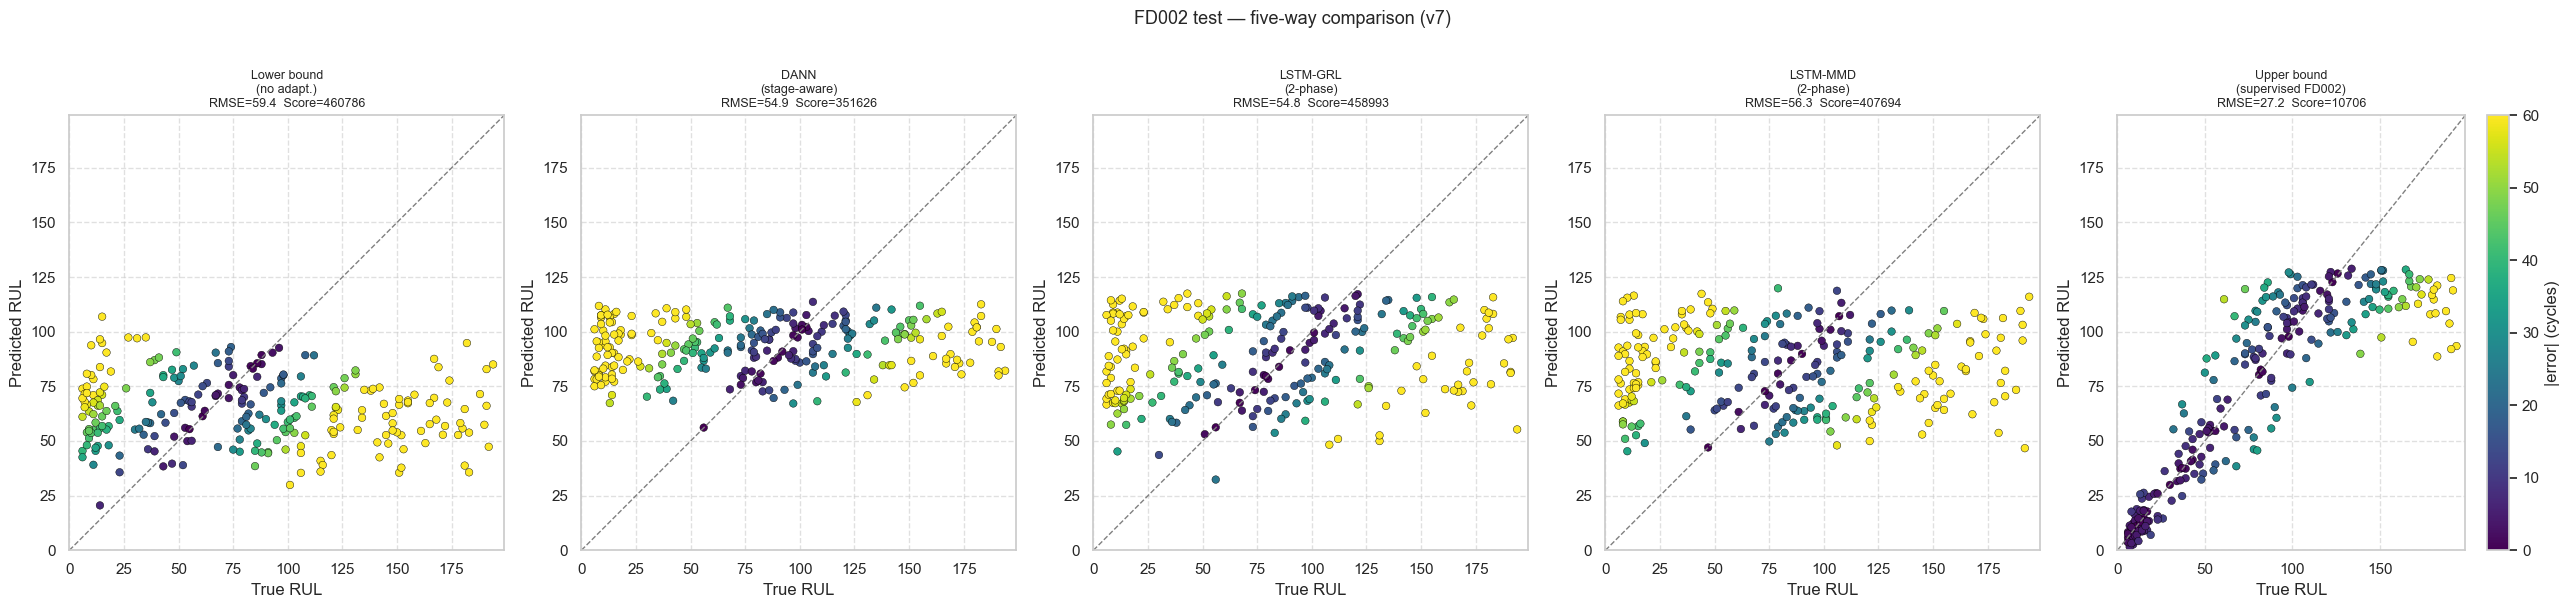

In [28]:
y_fd2 = splits["y_test_fd2"]
models_info = [
    ("Lower bound\n(no adapt.)",         np.clip(raw_lb,        0, None), lb_metrics),
    ("DANN\n(stage-aware)",              np.clip(raw_dann,      0, None), dann_metrics),
    ("LSTM-GRL\n(2-phase)",              np.clip(raw_grl_fd2,   0, None), grl_fd2_metrics),
    ("LSTM-MMD\n(2-phase)",              np.clip(raw_mmd_fd2,   0, None), mmd_fd2_metrics),
    ("Upper bound\n(supervised FD002)",  np.clip(raw_ub,        0, None), ub_metrics),
]

fig, axes = plt.subplots(1, 5, figsize=(26, 6))
lim = max(y_fd2.max(), max(p.max() for _,p,_ in models_info)) + 5

for ax, (title, yp, m) in zip(axes, models_info):
    ax.plot([0,lim],[0,lim], "--", color="gray", lw=1)
    errs = np.abs(yp - y_fd2)
    sc = ax.scatter(y_fd2, yp, c=errs, cmap="viridis",
                    s=30, edgecolor="black", linewidth=0.3, vmin=0, vmax=60)
    ax.set_xlim(0,lim); ax.set_ylim(0,lim)
    ax.set_xlabel("True RUL"); ax.set_ylabel("Predicted RUL")
    ax.set_title(f"{title}\nRMSE={m['rmse']:.1f}  Score={m['score']:.0f}", fontsize=9)
    ax.grid(linestyle="--", alpha=0.6)

plt.colorbar(sc, ax=axes[-1], label="|error| (cycles)")
plt.suptitle("FD002 test — five-way comparison (v7)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "v7_fd2_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## §29 · Sweep summary bar charts (4-way)

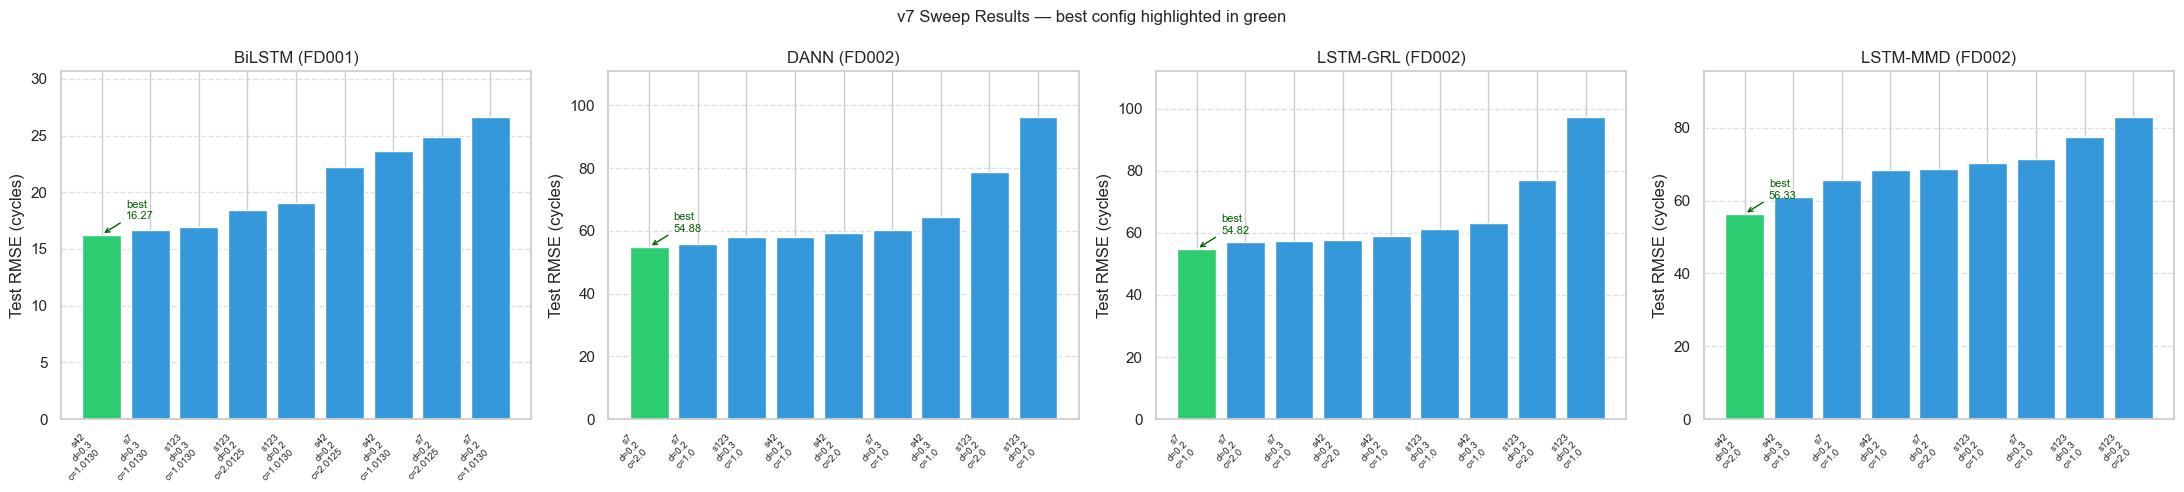


═════════════════════════════════════════════════
          FINAL v7 RESULTS SUMMARY
═════════════════════════════════════════════════
BiLSTM FD001   : RMSE=16.27  Score=402  Bias=+1.53
DANN   FD002   : RMSE=54.88  Score=351626  Bias=+11.65  Gap=14.0%
GRL    FD002   : RMSE=54.82  Score=458993  Bias=+7.72  Gap=14.2%
MMD    FD002   : RMSE=56.33  Score=407694  Bias=+2.32  Gap=9.5%
UB     FD002   : RMSE=27.18  Score=10706
═════════════════════════════════════════════════


In [29]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, df, title, col in [
    (axes[0], sweep_df,      "BiLSTM (FD001)",       "rmse"),
    (axes[1], dann_sweep_df, "DANN (FD002)",          "rmse"),
    (axes[2], grl_sweep_df,  "LSTM-GRL (FD002)",     "fd2_rmse"),
    (axes[3], mmd_sweep_df,  "LSTM-MMD (FD002)",     "fd2_rmse"),
]:
    vals  = df[col].values
    tags  = [t.replace("seed", "s").replace("_drop", "\nd=").replace("_clip","\nc=")
             .replace("_rul", "").replace("dann_","").replace("grl_","").replace("mmd_","")
             for t in df["tag"].values]
    colors = ["#2ecc71" if i == 0 else "#3498db" for i in range(len(vals))]
    ax.bar(range(len(vals)), vals, color=colors)
    ax.set_xticks(range(len(vals))); ax.set_xticklabels(tags, fontsize=7, rotation=45, ha="right")
    ax.set_ylabel("Test RMSE (cycles)")
    ax.set_title(title); ax.grid(axis="y", linestyle="--", alpha=0.6)
    ax.set_ylim(0, max(vals) * 1.15)
    ax.annotate(f"best\n{vals[0]:.2f}", xy=(0, vals[0]),
                xytext=(0.5, vals[0] + (max(vals)*0.05)),
                fontsize=8, color="darkgreen",
                arrowprops=dict(arrowstyle="->", color="darkgreen"))

plt.suptitle("v7 Sweep Results — best config highlighted in green", fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "v7_sweep_summary.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n═════════════════════════════════════════════════")
print("          FINAL v7 RESULTS SUMMARY")
print("═════════════════════════════════════════════════")
print(f"BiLSTM FD001   : RMSE={lstm_fd1_metrics['rmse']:.2f}  Score={lstm_fd1_metrics['score']:.0f}  Bias={lstm_fd1_metrics['bias']:+.2f}")
print(f"DANN   FD002   : RMSE={dann_metrics['rmse']:.2f}  Score={dann_metrics['score']:.0f}  Bias={dann_metrics['bias']:+.2f}  Gap={dann_gap_rmse:.1f}%")
print(f"GRL    FD002   : RMSE={grl_fd2_metrics['rmse']:.2f}  Score={grl_fd2_metrics['score']:.0f}  Bias={grl_fd2_metrics['bias']:+.2f}  Gap={grl_gap_rmse:.1f}%")
print(f"MMD    FD002   : RMSE={mmd_fd2_metrics['rmse']:.2f}  Score={mmd_fd2_metrics['score']:.0f}  Bias={mmd_fd2_metrics['bias']:+.2f}  Gap={mmd_gap_rmse:.1f}%")
print(f"UB     FD002   : RMSE={ub_metrics['rmse']:.2f}  Score={ub_metrics['score']:.0f}")
print("═════════════════════════════════════════════════")
